In [1]:
%pip install "dynamiqs>=0.3.0" cmaes scipy
#uncomment to install
#make sure you are using python 3.11 (py -3.11 -m venv .env, then .env\Scripts\activate for Windows)

Note: you may need to restart the kernel to use updated packages.


    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^


In [7]:
import dynamiqs as dq
import jax.numpy as jnp
from matplotlib import pyplot as plt
import jax

from jax import vmap, jit
from cmaes import SepCMA

from scipy.optimize import curve_fit
from scipy.optimize import least_squares

# dq.set_progress_meter(False)

In [8]:
# ── Hilbert space truncation ──────────────────────────────────────────────────
# NA: number of Fock states kept for the storage mode.
#     Must be large enough to contain |alpha|^2 mean photons.
#     With alpha ~ 2, <n> ~ 4, so NA=15 gives plenty of headroom.
# NB: buffer mode truncation. Buffer stays near vacuum (fast decay),
#     so NB=5 is sufficient.
NA = 15
NB = 5

# ── Hardware loss rates [MHz] ─────────────────────────────────────────────────
# KAPPA_B: buffer decay rate. Intentionally large (10 MHz) so the buffer
#          can be adiabatically eliminated, leaving effective 2-photon
#          dissipation on the storage. The condition kappa_b >> |g2| must hold.
# KAPPA_A: single-photon loss of the storage resonator (1 MHz).
#          This is the dominant error channel — it drives both phase flips
#          (fast, ~1/kappa_a) and, indirectly, bit flips (slow, exponential in alpha^2).
KAPPA_B = 10.0
KAPPA_A = 1.0

T_X_EVAL = 1.0
T_Z_EVAL = 50.0

# ── Loss weights ─────────────────────────────────────────────────────────────
# These control the trade-off between the three objectives.
# Increase LAMBDA_X / LAMBDA_Z to prioritize raw lifetime.
# Increase LAMBDA_BIAS to strictly enforce the target bias ratio.
LAMBDA_X    = 1.0    # weight on the T_X proxy reward
LAMBDA_Z    = 0.5    # weight on the T_Z proxy reward (lower: T_Z is harder to improve)
LAMBDA_BIAS = 0.1    # penalty weight for deviating from ETA_TARGET

# Target bias: eta = T_Z / T_X.
# Cat qubits are biased — we want T_Z >> T_X to exploit the noise asymmetry
ETA_TARGET  = 3000.0


ALPHA_TARGET = 2.0   # desired cat size (mean photon number = alpha^2 = 4)
LAMBDA_ALPHA = 0.5   # penalty weight — raise to enforce more strictly


In [11]:
#tz = decay of z operator => bit flip
#tx = decay of x operator => phase flip

@jit
def cat_loss_func(x):
  a, b = dq.destroy(NA, NB)

  #x[0] = g2.real, x[1] = g2.imag, x[2] = ed.real, x[3] = ed.imag
  g2 = x[0] + 1j * x[1]
  ed = x[2] + 1j * x[3]

  kappa_2   = 4.0 * jnp.abs(g2)**2 / KAPPA_B
  eps_2     = 2.0 * g2 * ed / KAPPA_B
  alpha = jnp.sqrt(jnp.abs(jnp.real(2.0 / kappa_2 * (eps_2 - KAPPA_A / 4.0))))


  #known hamiltonian for two-qubit dissipation
  H = g2.conj() * (a @ a @ b.dag()) + g2 * (a.dag() @ a.dag() @ b) - ed * b.dag() - ed.conj() * b

  jump_ops = [jnp.sqrt(KAPPA_B) * b,
                jnp.sqrt(KAPPA_A) * a] #losses for photon dissipation channels
  
  cat_pos = dq.tensor(dq.coherent(NA,  alpha), dq.fock(NB, 0))  # |+z_L> = |+alpha> x |0>_b
  cat_neg = dq.tensor(dq.coherent(NA, -alpha), dq.fock(NB, 0))  # |-z_L> = |-alpha> x |0>_b

  psi_x = (cat_pos + cat_neg) / jnp.sqrt(2)

  parity = (1j * jnp.pi * (a.dag() @ a)).expm()

  res_x = dq.mesolve(
        H, jump_ops, psi_x,
        jnp.array([0.0, T_X_EVAL]),  # only need the final time point
        exp_ops=[parity],
        options=dq.Options(progress_meter=False)
    )
  
  p0 = res_x.expects[0, 0].real
  p1 = res_x.expects[0, 1].real

  dp_dt = (p1 - p0) / T_X_EVAL
  tx_proxy = -1.0 / (dp_dt + 1e-8)
  sx_val = 1 / tx_proxy

   # Logical Z observable: Z_L = |+z_L><+z_L| - |-z_L><-z_L|
    #   - +1 when the state is in |+alpha> (logical |0>)
    #   - -1 when the state is in |-alpha> (logical |1>)
    #   - Requires alpha_est to construct — less robust than parity
  sz_storage = (dq.coherent(NA,  alpha) @ dq.coherent(NA,  alpha).dag()
                - dq.coherent(NA, -alpha) @ dq.coherent(NA, -alpha).dag())
  z_logical  = dq.tensor(sz_storage, dq.eye(NB))  # extend to full storage x buffer space

  # ── T_Z proxy: bit-flip lifetime ─────────────────────────────────────────
    # Initial state: |+z_L> = |+alpha> (<Z_L>=+1 at t=0)
    # Bit flips (|+alpha> -> |-alpha>) are exponentially suppressed in alpha^2,
    # so we probe at a much longer time T_Z_EVAL.
    # A higher <Z_L> at T_Z_EVAL means fewer bit flips, i.e., longer T_Z.
  res_z = dq.mesolve(
        H, jump_ops, cat_pos,
        jnp.array([0.0, T_Z_EVAL]),  # only need the final time point
        exp_ops=[z_logical],
        options=dq.Options(progress_meter=False)
    )
    # res_z.expects shape: [n_obs, n_times] -> take observable 0, final time
  sz_val = res_z.expects[0, -1].real
  #minimize deviation from a stable cat qubit
  # ── Bias proxy and penalty ────────────────────────────────────────────────
    # True bias would be eta = T_Z / T_X, requiring two full exponential fits.
    # Proxy: sz_val decays slowly (long T_Z -> sz near 1) while sx_val decays
    # fast (short T_X -> sx near 0). Their ratio is a rough stand-in for eta.
    # The epsilon (1e-6) prevents division by zero if parity collapses.
  bias_proxy   = sz_val / (jnp.abs(sx_val) + 1e-6)
    # Squared deviation from target: zero when bias_proxy == ETA_TARGET
  bias_penalty = (bias_proxy / ETA_TARGET - 1)**2

  alpha_penalty = (alpha - ALPHA_TARGET)**2

    # ── Combined loss ─────────────────────────────────────────────────────────
    # Negative rewards become positive losses (CMA-ES minimizes):
    #   -LAMBDA_X * sx_val   : reward for long T_X (sx close to +1 is good)
    #   -LAMBDA_Z * sz_val   : reward for long T_Z (sz close to +1 is good)
    #   +LAMBDA_BIAS * ...   : penalty for wrong bias ratio
    #  +LAMBDA_ALPHA * ...  : penalty for deviating from target alpha
  loss = (-LAMBDA_X * sx_val
            - LAMBDA_Z * sz_val
            + LAMBDA_BIAS * bias_penalty
            + LAMBDA_ALPHA * alpha_penalty)
  return loss

batched_cat_loss_func = jit(vmap(cat_loss_func))

In [ ]:
BATCH_SIZE = 12   # CMA-ES population size (number of candidates per epoch)
N_EPOCHS   = 60   # total number of optimization epochs

# ── CMA-ES setup ─────────────────────────────────────────────────────────────
# mean0: starting point for the search distribution.
#        We start near the nominal operating point from the challenge notebook.
# sigma0: initial exploration scale (std dev of the search distribution).
#         0.3 lets the optimizer explore a reasonable neighbourhood before tightening.
mean0  = jnp.array([1.0, 0.0, 4.0, 0.0])
sigma0 = 0.3

optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    # Hard bounds on each knob — prevents unphysical or numerically unstable regimes
    bounds=jnp.array([
        [0.1,  5.0],   # Re(g2): must be positive for stabilization; cap at 5 MHz
        [-2.0, 2.0],   # Im(g2): phase of the coupling
        [0.5, 10.0],   # Re(eps_d): buffer drive amplitude; must be positive
        [-2.0, 2.0],   # Im(eps_d): phase of the buffer drive
    ]),
    population_size=BATCH_SIZE,
    seed=0,            # fixed seed for reproducibility
)

# ── Logging ───────────────────────────────────────────────────────────────────
mean_history     = []   # optimizer mean (best estimate) at each epoch
loss_history     = []   # mean loss over the population at each epoch
loss_std_history = []   # std of losses (measures population spread / convergence)

# ── Training loop ────────────────────────────────────────────────────────────
for epoch in range(N_EPOCHS):

    # 1. Sample BATCH_SIZE candidate parameter vectors from the current
    #    Gaussian search distribution N(mean, sigma^2 * C)
    xs = jnp.array([optimizer.ask() for _ in range(optimizer.population_size)])

    # 2. Evaluate all candidates in a single batched JIT call
    losses = batched_cat_loss_func(xs)

    # 3. Tell CMA-ES the (solution, loss) pairs so it can update its distribution.
    #    CMA-ES expects the list sorted by ascending loss (best = lowest first).
    solutions = [(xs[i], float(losses[i])) for i in range(len(xs))]
    solutions.sort(key=lambda sv: sv[1])
    optimizer.tell(solutions)

    # 4. Log statistics for plotting
    mean_history.append(optimizer.mean.copy())        # current best-estimate params
    loss_history.append(float(losses.mean()))          # average loss this epoch
    loss_std_history.append(float(losses.std()))       # spread of losses

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | mean loss {loss_history[-1]:.4f} | mean params {optimizer.mean}")

# Convert to JAX arrays for easier slicing during plotting
mean_history     = jnp.array(mean_history)
loss_history     = jnp.array(loss_history)
loss_std_history = jnp.array(loss_std_history)

Epoch   0 | mean loss -0.7938 | mean params [1.1620389 0.0486031 4.071603  0.3102888]
Epoch  10 | mean loss -1.0598 | mean params [ 1.2518997  -0.34299985  6.112827    0.9748279 ]


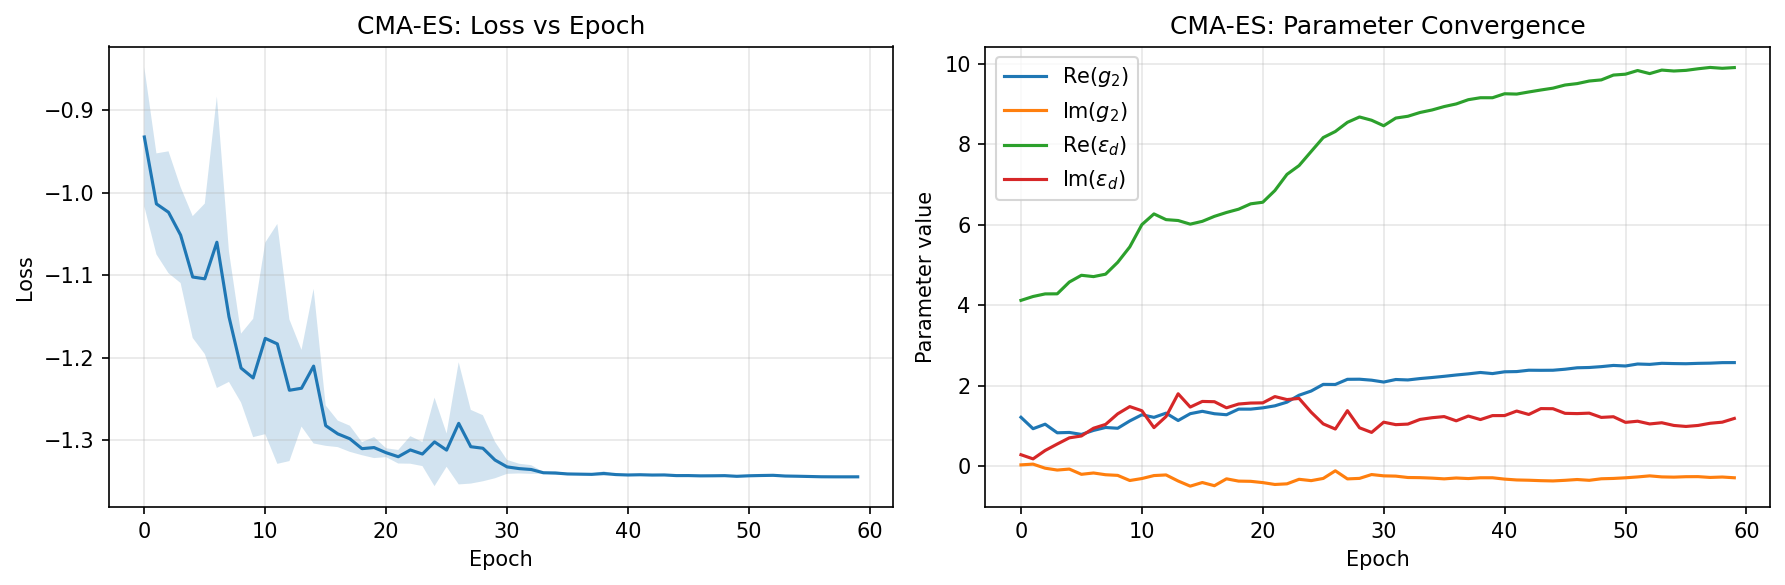

In [6]:
epochs = jnp.arange(N_EPOCHS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# ── Plot 1: Loss vs epoch ─────────────────────────────────────────────────────
# A downward trend means the optimizer is finding better parameter settings.
# The shaded band shows the spread across the population — it should narrow
# as CMA-ES converges and sigma shrinks.
ax = axes[0]
ax.plot(epochs, loss_history, label="Mean loss")
ax.fill_between(epochs,
                loss_history - loss_std_history,
                loss_history + loss_std_history,
                alpha=0.2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CMA-ES: Loss vs Epoch")
ax.grid(True, alpha=0.3)

# ── Plot 2: Parameter convergence ────────────────────────────────────────────
# Each line is one of the four knobs. They should plateau as the optimizer
# finds the optimal operating point. Im(g2) and Im(eps_d) converging near 0
# would suggest the optimal drive phases are real-valued.
ax = axes[1]
labels = [r"$\mathrm{Re}(g_2)$", r"$\mathrm{Im}(g_2)$",
          r"$\mathrm{Re}(\epsilon_d)$", r"$\mathrm{Im}(\epsilon_d)$"]
for k, lbl in enumerate(labels):
    ax.plot(epochs, mean_history[:, k], label=lbl)
ax.set_xlabel("Epoch")
ax.set_ylabel("Parameter value")
ax.set_title("CMA-ES: Parameter Convergence")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()